In [91]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize
from scipy.signal import find_peaks

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [60]:
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures'

In [3]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [4]:
seq_sums = []
seq_pars = []
seq_pos = []
for asset in assets:
    try:
        print(asset.session_id)
        derived_dir = asset.derived_dir / 'glutamate' /'glutamate_analysis'
        seq_sum = pd.read_csv(os.path.join(derived_dir, 'sequence_summary_table.csv'))
        seq_sum['dmd1_depth'] = [asset.metadata['dmd1_depth']]*len(seq_sum)
        seq_sum['dmd2_depth'] = [asset.metadata['dmd2_depth']]*len(seq_sum)
        seq_par = pd.read_parquet(derived_dir / 'sequence_per_image_table.parquet')
        seq_pos_ = pd.read_parquet(derived_dir / 'sequence_position_table.parquet')
        seq_sums.append(seq_sum)

        seq_pars.append(seq_par)
        seq_pos.append(seq_pos_)
    except:
        pass

seq_summary = pd.concat(seq_sums)
seq_per_image = pd.concat(seq_pars)
seq_position = pd.concat(seq_pos)

803496_2025-07-25_13-02-10
803496_2025-07-28_08-04-39
803496_2025-07-29_13-34-35
803496_2025-07-30_10-05-23
803496_2025-07-31_09-43-28
803496_2025-08-01_13-22-49
804730_2025-07-25_14-08-35
804730_2025-07-28_13-57-34
804730_2025-07-29_14-55-04
804730_2025-07-30_11-11-11
804730_2025-07-31_11-45-27
804730_2025-08-01_14-22-38
804733_2025-07-25_15-17-00
804733_2025-07-28_19-00-06
804733_2025-07-29_16-02-24
804733_2025-07-30_12-59-44
804733_2025-07-31_13-29-01
804733_2025-08-01_15-20-32
810196_2025-07-25_16-24-20
810196_2025-07-28_19-59-05
810196_2025-07-29_17-02-41
810196_2025-07-31_08-28-08
810196_2025-07-31_14-19-46
810196_2025-08-01_16-37-27
809047_2025-10-29_10-16-32
809047_2025-10-30_10-06-43
809047_2025-10-31_12-00-50
809047_2025-11-01_17-51-59
809047_2025-11-05_10-13-00
809047_2025-11-06_11-05-31
803121_2025-10-29_11-19-29
803121_2025-10-30_11-13-32
803121_2025-10-31_13-05-26
803121_2025-11-01_19-00-21
803121_2025-11-05_11-16-57
803121_2025-11-06_12-12-23
826033_2026-02-21_09-23-34
8

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_34544\3161649996.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  seq_summary = pd.concat(seq_sums)


In [5]:
seq_per_image

,session_id,subject_id,dmd,synapse_id,stimulus_name,stimulus_label,n_positions,n_sequences,r0,rlast,...,overall_slope,overall_slope_norm,early_slope,late_slope,sequence_label,image_selectivity_score,ranking_score,image_rank_within_synapse,rank_basis,is_preferred_ranked_image
0,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk01378.tiff,imk01378,21,40,4.135909,-3.317766,...,0.176119,0.042583,-0.015838,0.653529,stable,-34.922383,45.880193,5,response_amplitude,False
1,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk01220.tiff,imk01220,17,40,4.002009,3.400045,...,0.314888,0.078682,0.139810,1.405141,stable,64.178829,130.824089,2,response_amplitude,False
2,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk00459.tiff,imk00459,16,40,2.642996,11.732948,...,0.526522,0.199214,0.181800,1.475654,stable,-14.799073,63.128745,4,response_amplitude,False
3,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk01643.tiff,imk01643,13,39,3.792312,5.586604,...,0.053110,0.014005,0.095214,-0.118465,stable,156.407801,209.877494,1,response_amplitude,True
4,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk00942.tiff,imk00942,14,39,9.852383,9.400597,...,-0.567097,-0.057559,-0.757631,0.229945,stable,-96.587349,-6.975492,7,response_amplitude,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\69022.tiff,69022,14,41,4.139674,2.922333,...,-0.229843,-0.055522,-0.097099,-0.697211,stable,9.523214,40.676187,3,response_amplitude,False
3,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\McGill_stairs.tiff,McGill_stairs,13,42,3.433658,5.620232,...,0.388975,0.113283,0.261582,0.773428,stable,-23.648170,12.243572,6,response_amplitude,False
4,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\216066.tiff,216066,15,42,1.891201,-0.229533,...,0.089876,0.047523,-0.035940,0.485189,stable,-36.478776,1.245909,7,response_amplitude,False
5,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\41006.tiff,41006,17,41,5.208662,27.667132,...,0.153581,0.029486,-0.248456,1.619099,stable,-9.750158,24.156154,5,response_amplitude,False


In [6]:
seq_paths = [glob.glob(os.path.join(asset.derived_dir,'**','glutamate_sequence_df.npz'),recursive=True)[0] for asset in assets]

In [ ]:
im_colors = [
    '#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
    '#e1bee7', '#d7ccc8',
    '#9fd3f2']

In [135]:
# Facilitation example
mouse = '810196'
example_sess = f'{mouse}_2025-07-28_19-59-05'
example_dmd = 2
example_synapse = '0015'

example_datapath = [path for path in seq_paths if mouse in path][1]

seq_data = np.load(example_datapath,allow_pickle=True)['data'][0]

keys = list(seq_data[f'DMD{example_dmd}']['image_identity'].keys())

syn_im_df = seq_per_image[(seq_per_image['session_id']==example_sess)
                           &(seq_per_image['synapse_id']==f'DMD{example_dmd}_syn{example_synapse}')]

pref_image =  syn_im_df[syn_im_df['image_rank_within_synapse']==1]['stimulus_name'].values[0]

syn_pos_df = seq_position[(seq_position['session_id']==example_sess)
                           &(seq_position['synapse_id']==f'DMD{example_dmd}_syn{example_synapse}')]

<IPython.core.display.Javascript object>


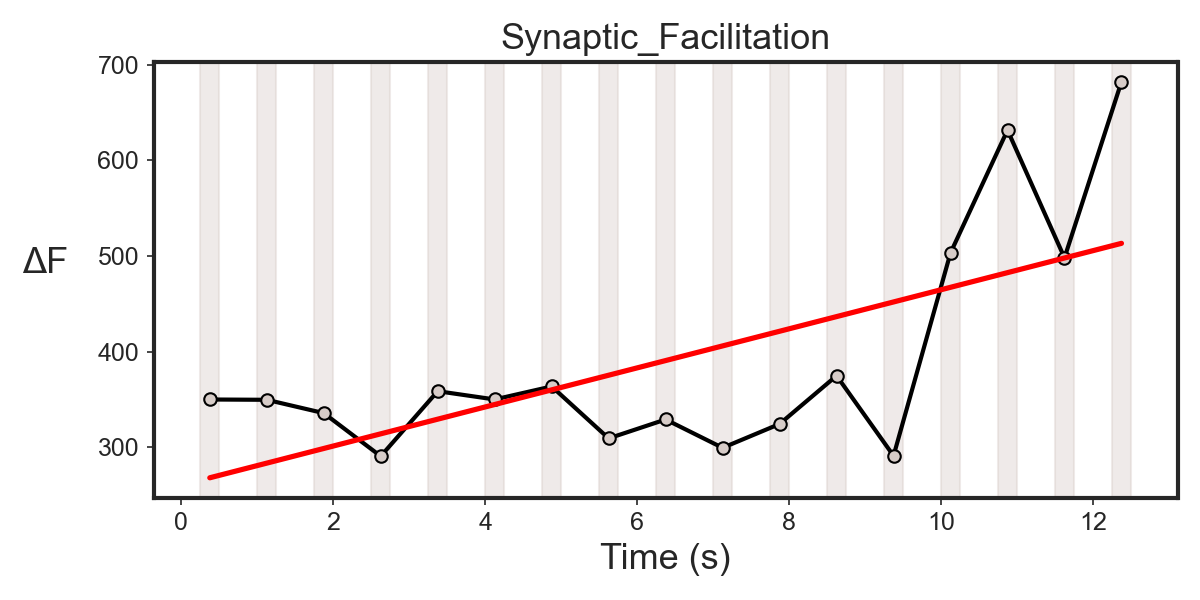

In [148]:
syn = int(example_synapse.split('0')[-1])
im = keys.index(pref_image)

mean_im_resps = (
    seq_data[f'DMD{example_dmd}']['image_identity'][pref_image]['repeated']['mean']
    .transpose(1, 0, 2)[syn][:]
)

resp_means = [np.mean(resp) for resp in mean_im_resps]
peaks = [resp[find_peaks(resp, distance=120)[0][0]] for resp in mean_im_resps]

shape = mean_im_resps.shape
concat_traces = mean_im_resps.reshape(shape[0] * shape[1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

mean = concat_traces
mean_rolling = pd.DataFrame(concat_traces).rolling(10, min_periods=1).mean()

time = np.linspace(0, len(mean) / 200, len(mean))
# ax.plot(time, mean, color='k')

ax.set_xlabel('Time (s)')
ax.set_ylabel('\u0394F', rotation=0, labelpad=25)

fs = 200
flash_start = 50 / fs      # 0.25 s
flash_dur = 50 / fs        # 0.25 s
gray_dur = 100 / fs        # 0.5 s
cycle_dur = flash_dur + gray_dur

n_flashes = shape[0]

for spine in ['left', 'right', 'top', 'bottom']:
    ax.spines[spine].set_linewidth(2)

windows = []

for i in range(n_flashes):
    start = flash_start + i * cycle_dur
    end = start + flash_dur
    ax.axvspan(start, end, alpha=0.4, color=im_colors[im])

    window_t = np.mean([start, end])
    windows.append(window_t)

windows = np.asarray(windows)
peaks = np.asarray(peaks)

# plot measured peaks
ax.plot(
    windows,
    resp_means,
    color='k',
    marker='o',
    lw=2,
    markerfacecolor=im_colors[im],
    label='Peak response'
)

# -------------------------------------------------------
# Slope fitting
# -------------------------------------------------------
use_quantiles = False   # set True to fit on quantile-binned peaks
n_quantiles = 4         # only used if use_quantiles = True

if not use_quantiles:
    # simple linear fit to all peak points
    slope, intercept = np.polyfit(windows, resp_means, 1)
    fit_y = slope * windows + intercept

    ax.plot(
        windows,
        fit_y,
        color='red',
        lw=2.5,
        label=f'Linear fit (slope = {slope:.4f})'
    )

else:
    # quantile/bin-based fit across the ordered presentations
    fit_df = pd.DataFrame({
        'window': windows,
        'peak': peaks,
        'presentation_idx': np.arange(len(windows))
    })

    fit_df['quantile'] = pd.qcut(
        fit_df['presentation_idx'],
        q=n_quantiles,
        labels=False,
        duplicates='drop'
    )

    quant_summary = (
        fit_df.groupby('quantile', observed=True)
        .agg(
            window=('window', 'mean'),
            peak=('peak', 'mean')
        )
        .reset_index(drop=True)
    )

    qx = quant_summary['window'].to_numpy()
    qy = quant_summary['peak'].to_numpy()

    slope, intercept = np.polyfit(qx, qy, 1)
    fit_y = slope * qx + intercept

    # optional: show quantile means
    ax.plot(
        qx,
        qy,
        color='red',
        marker='o',
        lw=0,
        ms=7,
        label='Quantile means'
    )

    ax.plot(
        qx,
        fit_y,
        color='red',
        lw=2.5,
        label=f'Quantile fit (slope = {slope:.4f})'
    )

ax.set_title('Synaptic_Facilitation')
# ax.legend(frameon=False)
fig.tight_layout()

filen = 'Synaptic_Facilitation_example'
save_figure(fig, os.path.join(savepath, filen), formats=['.pdf', '.png'], dpi=300)

In [153]:
# Facilitation example
mouse = '803121'
example_sess = f'{mouse}_2025-11-01_19-00-21'
example_dmd = 2
example_synapse = '0065'

example_datapath = [path for path in seq_paths if mouse in path][3]

seq_data = np.load(example_datapath,allow_pickle=True)['data'][0]

keys = list(seq_data[f'DMD{example_dmd}']['image_identity'].keys())

syn_im_df = seq_per_image[(seq_per_image['session_id']==example_sess)
                           &(seq_per_image['synapse_id']==f'DMD{example_dmd}_syn{example_synapse}')]

pref_image =  syn_im_df[syn_im_df['image_rank_within_synapse']==1]['stimulus_name'].values[0]

syn_pos_df = seq_position[(seq_position['session_id']==example_sess)
                           &(seq_position['synapse_id']==f'DMD{example_dmd}_syn{example_synapse}')]

<IPython.core.display.Javascript object>


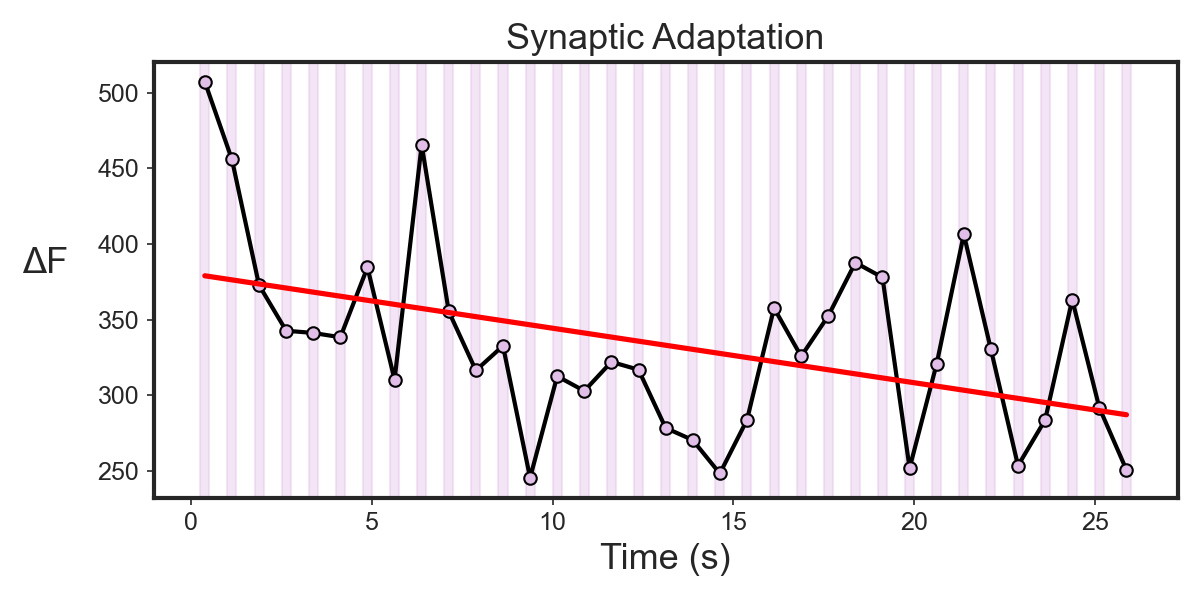

In [155]:
syn = int(example_synapse.split('0')[-1])
im = keys.index(pref_image)

mean_im_resps = (
    seq_data[f'DMD{example_dmd}']['image_identity'][pref_image]['repeated']['mean']
    .transpose(1, 0, 2)[syn][:]
)

resp_means = [np.mean(resp) for resp in mean_im_resps]
peaks = [resp[find_peaks(resp, distance=120)[0][0]] for resp in mean_im_resps]

shape = mean_im_resps.shape
concat_traces = mean_im_resps.reshape(shape[0] * shape[1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

mean = concat_traces
mean_rolling = pd.DataFrame(concat_traces).rolling(10, min_periods=1).mean()

time = np.linspace(0, len(mean) / 200, len(mean))
# ax.plot(time, mean, color='k')

ax.set_xlabel('Time (s)')
ax.set_ylabel('\u0394F', rotation=0, labelpad=25)

fs = 200
flash_start = 50 / fs      # 0.25 s
flash_dur = 50 / fs        # 0.25 s
gray_dur = 100 / fs        # 0.5 s
cycle_dur = flash_dur + gray_dur

n_flashes = shape[0]

for spine in ['left', 'right', 'top', 'bottom']:
    ax.spines[spine].set_linewidth(2)

windows = []

for i in range(n_flashes):
    start = flash_start + i * cycle_dur
    end = start + flash_dur
    ax.axvspan(start, end, alpha=0.4, color=im_colors[im])

    window_t = np.mean([start, end])
    windows.append(window_t)

windows = np.asarray(windows)
peaks = np.asarray(peaks)

# plot measured peaks
ax.plot(
    windows,
    resp_means,
    color='k',
    marker='o',
    lw=2,
    markerfacecolor=im_colors[im],
    label='Peak response'
)

# -------------------------------------------------------
# Slope fitting
# -------------------------------------------------------
use_quantiles = False   # set True to fit on quantile-binned peaks
n_quantiles = 4         # only used if use_quantiles = True

if not use_quantiles:
    # simple linear fit to all peak points
    slope, intercept = np.polyfit(windows, resp_means, 1)
    fit_y = slope * windows + intercept

    ax.plot(
        windows,
        fit_y,
        color='red',
        lw=2.5,
        label=f'Linear fit (slope = {slope:.4f})'
    )

else:
    # quantile/bin-based fit across the ordered presentations
    fit_df = pd.DataFrame({
        'window': windows,
        'peak': peaks,
        'presentation_idx': np.arange(len(windows))
    })

    fit_df['quantile'] = pd.qcut(
        fit_df['presentation_idx'],
        q=n_quantiles,
        labels=False,
        duplicates='drop'
    )

    quant_summary = (
        fit_df.groupby('quantile', observed=True)
        .agg(
            window=('window', 'mean'),
            peak=('peak', 'mean')
        )
        .reset_index(drop=True)
    )

    qx = quant_summary['window'].to_numpy()
    qy = quant_summary['peak'].to_numpy()

    slope, intercept = np.polyfit(qx, qy, 1)
    fit_y = slope * qx + intercept

    # optional: show quantile means
    ax.plot(
        qx,
        qy,
        color='red',
        marker='o',
        lw=0,
        ms=7,
        label='Quantile means'
    )

    ax.plot(
        qx,
        fit_y,
        color='red',
        lw=2.5,
        label=f'Quantile fit (slope = {slope:.4f})'
    )

ax.set_title('Synaptic Adaptation')
# ax.legend(frameon=False)
fig.tight_layout()

filen = 'Synaptic_Adaptation_example'
save_figure(fig, os.path.join(savepath, filen), formats=['.pdf', '.png'], dpi=300)